/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Shallow Accuracy: 0.767
Medium Accuracy: 0.867
Deep Accuracy: 0.833


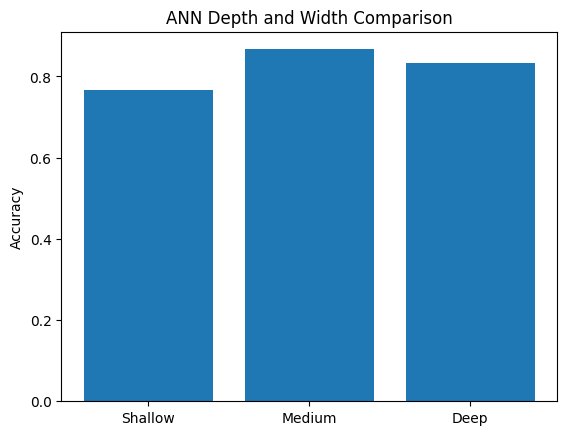

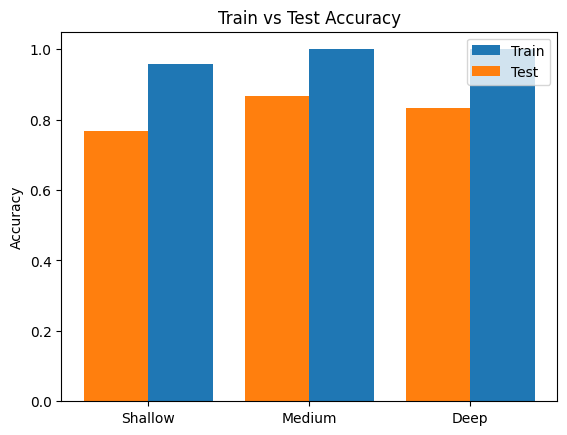

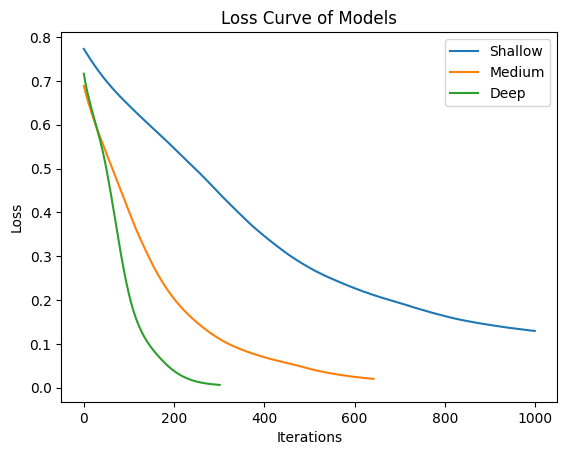

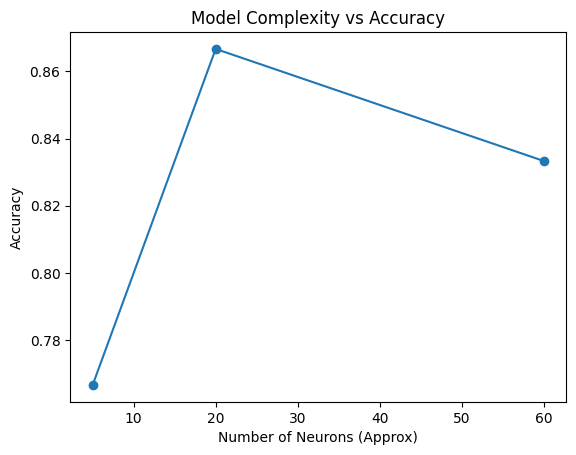

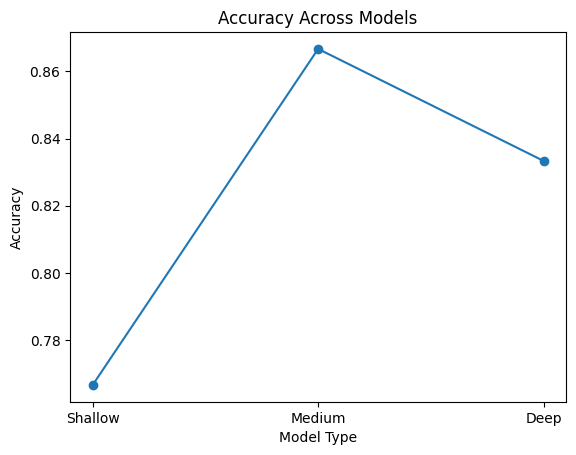

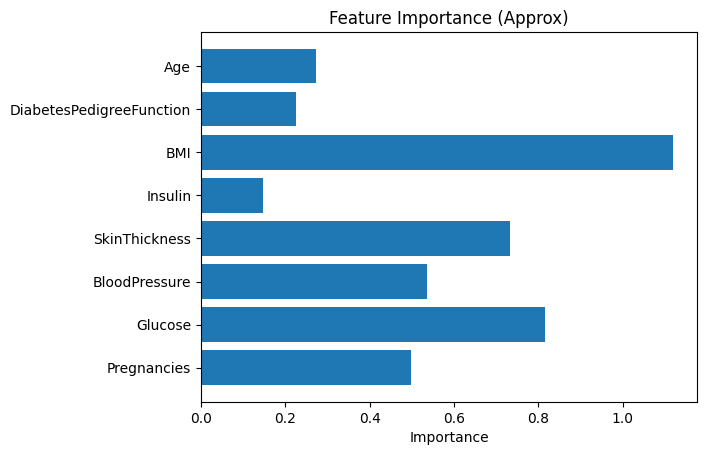

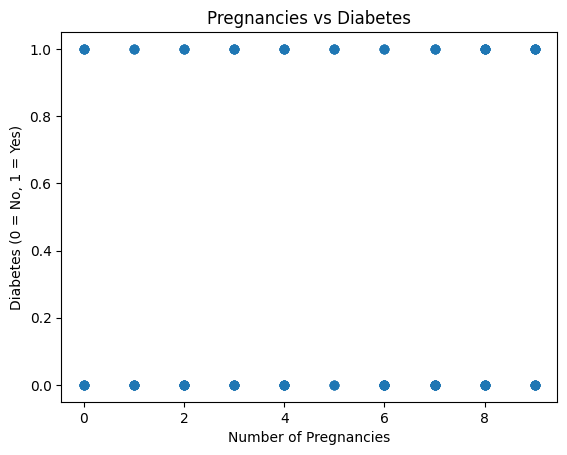

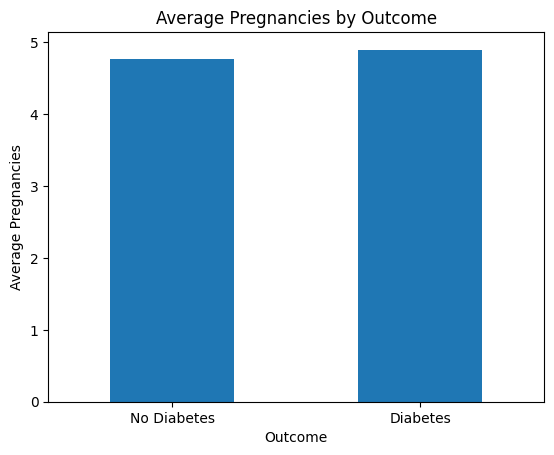

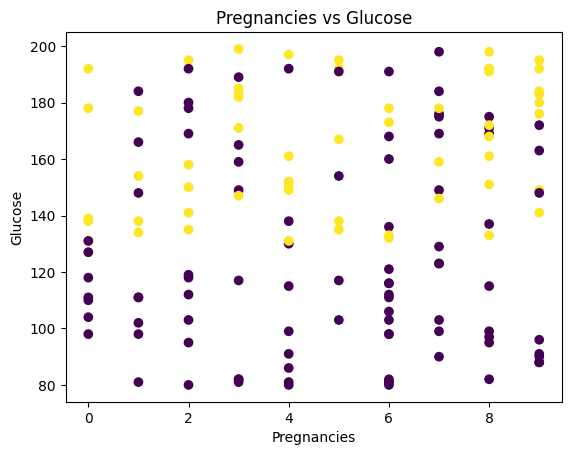

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score


# Load data
data = pd.read_csv("diabetes_dataset.csv")

X = data.drop("Outcome", axis=1)
y = data["Outcome"]


# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Define models
model1 = MLPClassifier(hidden_layer_sizes=(5,), max_iter=1000, random_state=42)
model2 = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)
model3 = MLPClassifier(hidden_layer_sizes=(20, 20, 20), max_iter=1000, random_state=42)

models = [model1, model2, model3]
names = ["Shallow", "Medium", "Deep"]


# Train and evaluate
accuracies = []

for i in range(len(models)):
    models[i].fit(X_train, y_train)
    pred = models[i].predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)
    print(names[i], "Accuracy:", round(acc, 3))


# Accuracy comparison
plt.figure()
plt.bar(names, accuracies)
plt.title("ANN Depth and Width Comparison")
plt.ylabel("Accuracy")
plt.show()


# Train vs Test accuracy
train_acc = []

for i in range(len(models)):
    pred_train = models[i].predict(X_train)
    acc_train = accuracy_score(y_train, pred_train)
    train_acc.append(acc_train)

plt.figure()
x = range(len(names))

plt.bar(x, train_acc, width=0.4, label="Train", align='edge')
plt.bar(x, accuracies, width=-0.4, label="Test", align='edge')

plt.xticks(x, names)
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.legend()
plt.show()


# Loss curves
plt.figure()

for i in range(len(models)):
    plt.plot(models[i].loss_curve_, label=names[i])

plt.title("Loss Curve of Models")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()


# Model complexity vs accuracy
complexity = [5, 20, 60]

plt.figure()
plt.plot(complexity, accuracies, marker='o')

plt.title("Model Complexity vs Accuracy")
plt.xlabel("Number of Neurons (Approx)")
plt.ylabel("Accuracy")
plt.show()


# Accuracy trend
plt.figure()
plt.plot(names, accuracies, marker='o')

plt.title("Accuracy Across Models")
plt.xlabel("Model Type")
plt.ylabel("Accuracy")
plt.show()


# Feature importance (approx)
weights = np.abs(model1.coefs_[0]).mean(axis=1)
features = X.columns

plt.figure()
plt.barh(features, weights)

plt.title("Feature Importance (Approx)")
plt.xlabel("Importance")
plt.show()


# Pregnancy analysis
plt.figure()
plt.scatter(data["Pregnancies"], data["Outcome"])

plt.title("Pregnancies vs Diabetes")
plt.xlabel("Number of Pregnancies")
plt.ylabel("Diabetes (0 = No, 1 = Yes)")
plt.show()


# Average pregnancies by outcome
avg_preg = data.groupby("Outcome")["Pregnancies"].mean()

plt.figure()
avg_preg.plot(kind='bar')

plt.title("Average Pregnancies by Outcome")
plt.ylabel("Average Pregnancies")
plt.xticks([0, 1], ["No Diabetes", "Diabetes"], rotation=0)
plt.show()


# Pregnancies vs glucose
plt.figure()
plt.scatter(data["Pregnancies"], data["Glucose"], c=data["Outcome"])

plt.title("Pregnancies vs Glucose")
plt.xlabel("Pregnancies")
plt.ylabel("Glucose")
plt.show()